# Data Cleaning Notebook Overview
This notebook performs a step-by-step cleaning and visualization of raw real estate data:
- Load raw data
- Remove duplicates and unneeded columns
- Handle missing values and outliers
- Fix data types for modeling
- Generate visualizations and save cleaned CSV for training

### Imports & Setup
Import standard data libraries for cleaning and visualization: pandas, numpy, seaborn, and matplotlib.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### 1) Load Raw Data
Read the original compressed CSV (`realtor-data.zip`) into a pandas DataFrame and display the initial row count to track how cleaning steps affect dataset size.

In [3]:
# 1. LOAD DATA
print("Loading dataset... (This might take a few seconds)")
df = pd.read_csv('realtor-data.zip')

print(f"Original Dataset Size: {len(df):,} rows")

Loading dataset... (This might take a few seconds)
Original Dataset Size: 2,226,382 rows


### 2) Remove Duplicate Rows
Drop duplicate records to avoid repeated data biasing the analysis and show the updated row count.

In [4]:
# 2. REMOVE DUPLICATES
df = df.drop_duplicates()
print(f"After removing duplicates: {len(df):,} rows")

After removing duplicates: 2,226,382 rows


### 3) Drop Unnecessary Columns
Drop columns that are not useful for modeling (e.g., broker info, status, etc.) to simplify the dataset and avoid noise.

In [5]:
# 3. DROP USELESS COLUMNS 'brokered_by', 'status', 'prev_sold_date', 'street'
cols_to_drop = ['brokered_by', 'status', 'prev_sold_date', 'street']

# We use errors='ignore' just in case the columns are already gone
df = df.drop(columns=cols_to_drop, errors='ignore')

print(f"Columns removed. Current columns: {list(df.columns)}")

Columns removed. Current columns: ['price', 'bed', 'bath', 'acre_lot', 'city', 'state', 'zip_code', 'house_size']


### 4) Handle Missing Values
Drop rows missing key fields (price, bed, bath, lot/house size, zip/city/state) to keep only complete records for basic modeling steps.

In [ ]:
# 4. HANDLE MISSING VALUES
# If we guess (impute) these values wrong, we confuse the AI.
cols_to_check = ['price', 'bed', 'bath', 'acre_lot', 'house_size', 'zip_code', 'city', 'state']
df = df.dropna(subset=cols_to_check)
print(f"After dropping missing values: {len(df):,} rows")

After dropping missing values: 1,360,347 rows


### 5) Filter Outliers / Sanity Checks
Apply rules to remove extreme or invalid records (price, house size, beds/baths, and exclude territories). Compute `lot_size_sqft` from `acre_lot` and remove `acre_lot`.

In [7]:
# 5. FILTER OUTLIERS (The "Sanity Check")
# We define "Rules" for what a valid house looks like.

# Rule A: Price must be realistic for a house (e.g., between $10k and $10M)
# This removes rentals listed as "$1,500" or errors listed as "$0"
df = df[(df['price'] >= 10000) & (df['price'] <= 10000000)]

# Rule B: Area (Square feet). remove tiny sheds (< 100 sqft) or massive errors
df = df[(df['house_size'] >= 100) & (df['house_size'] <= 20000)]

# Rule C: Beds and Baths. Anything over 20 is usually an error (or an apartment complex)
df = df[(df['bed'] <= 20) & (df['bath'] <= 20)]

# # Rule D: Remove Puerto Rico/Virgin Islands
df = df[~df['state'].isin(['Puerto Rico', 'Virgin Islands'])]

# Convert acres to sq ft (1 acre = 43,560 sq ft)
if 'acre_lot' in df.columns:
    df['lot_size_sqft'] = df['acre_lot'] * 43560

df = df.drop(columns=['acre_lot'], errors='ignore')

print(f"After filtering outliers: {len(df):,} rows")

After filtering outliers: 1,354,993 rows


### 6) Data Type Fixes
Fix data types for categorical features (convert `zip_code`, `city`, `state` to string) to ensure correct handling by CatBoost and other tools.

In [8]:
# 5. DATA TYPE FIXES (Critical for CatBoost)
# Zip Codes look like numbers (90210), but they are actually categories.
# If we leave them as numbers, the AI thinks 90210 > 10001 (mathematically), which is wrong.
df['zip_code'] = df['zip_code'].astype(str).str.replace(r'\.0$', '', regex=True)
df['city'] = df['city'].astype(str)
df['state'] = df['state'].astype(str)

### 7) Visualize Price Distribution
Plot a histogram (log scale) of house prices to inspect the distribution after cleaning.


Generating Price Distribution Graph...


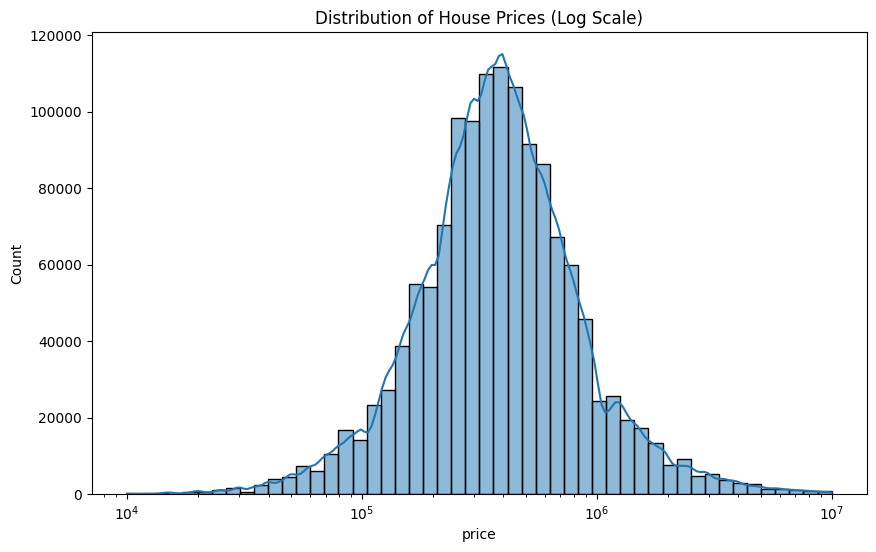

In [9]:
# 6. VISUALIZE THE CLEAN DATA
print("\nGenerating Price Distribution Graph...")
plt.figure(figsize=(10, 6))
# transform price to log scale for better visibility (since housing prices vary wildly)
sns.histplot(df['price'], bins=50, kde=True, log_scale=True)
plt.title('Distribution of House Prices (Log Scale)')
plt.show()

### 8) Additional Visualizations
Generate additional plots: listings per state, median price by state, correlation heatmap, and price vs house size scatter (log-log), to explore relationships and spot remaining issues.


Generating additional visualizations: Listings by state, Median price by state, Correlation heatmap, and Price vs House Size scatter...


/tmp/ipykernel_451058/2394708406.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_counts.values, y=state_counts.index, palette='viridis')


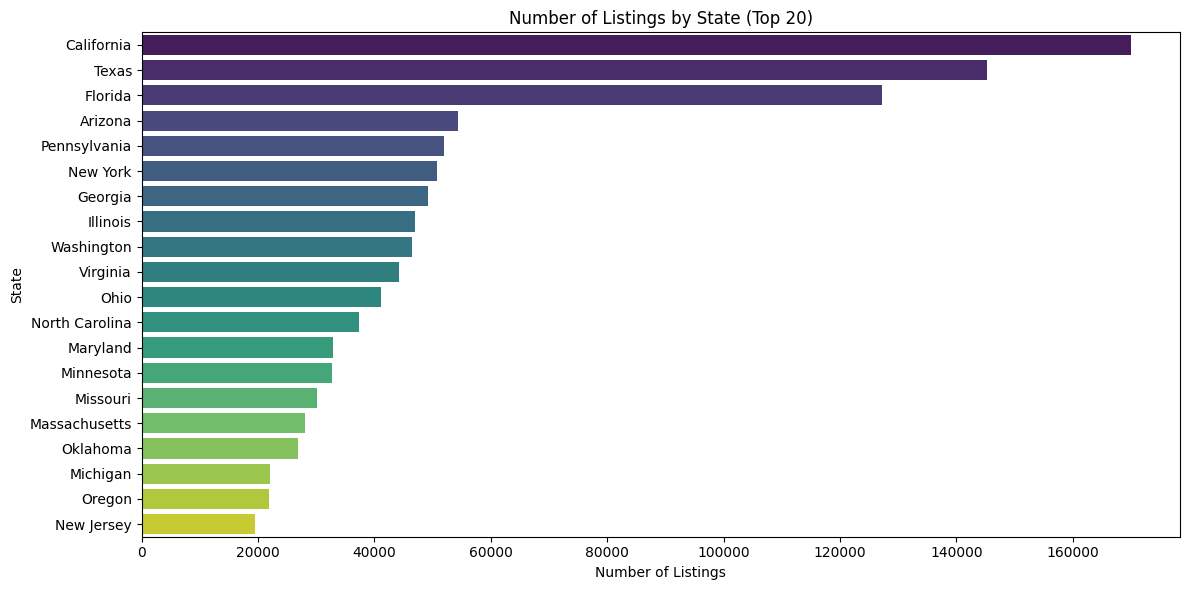

/tmp/ipykernel_451058/2394708406.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=median_price.values, y=median_price.index, palette='magma')


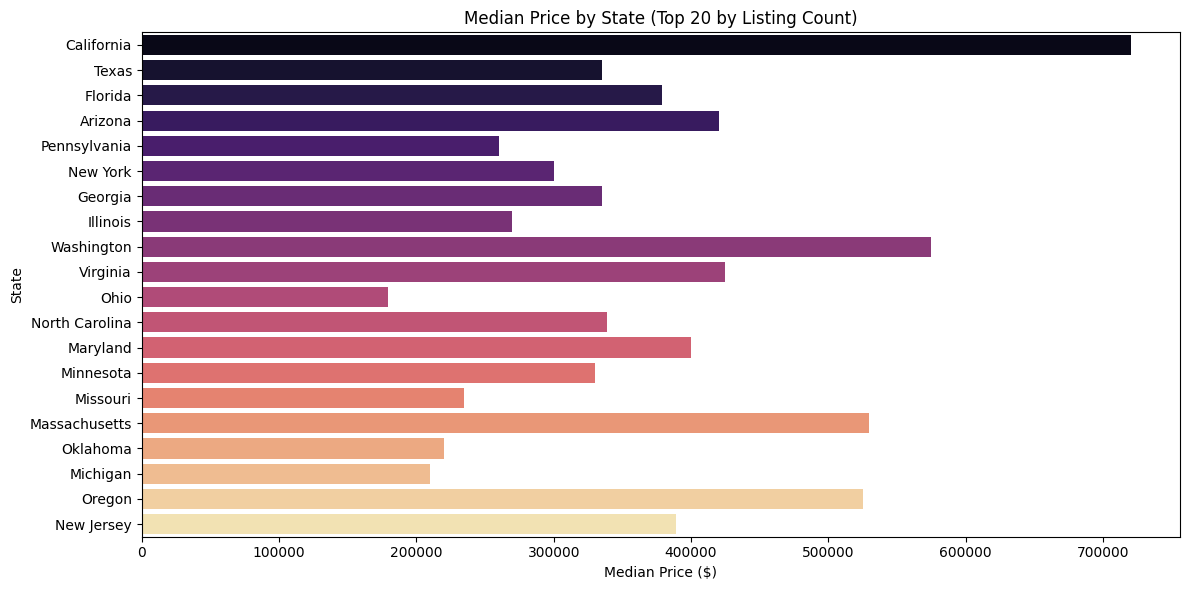

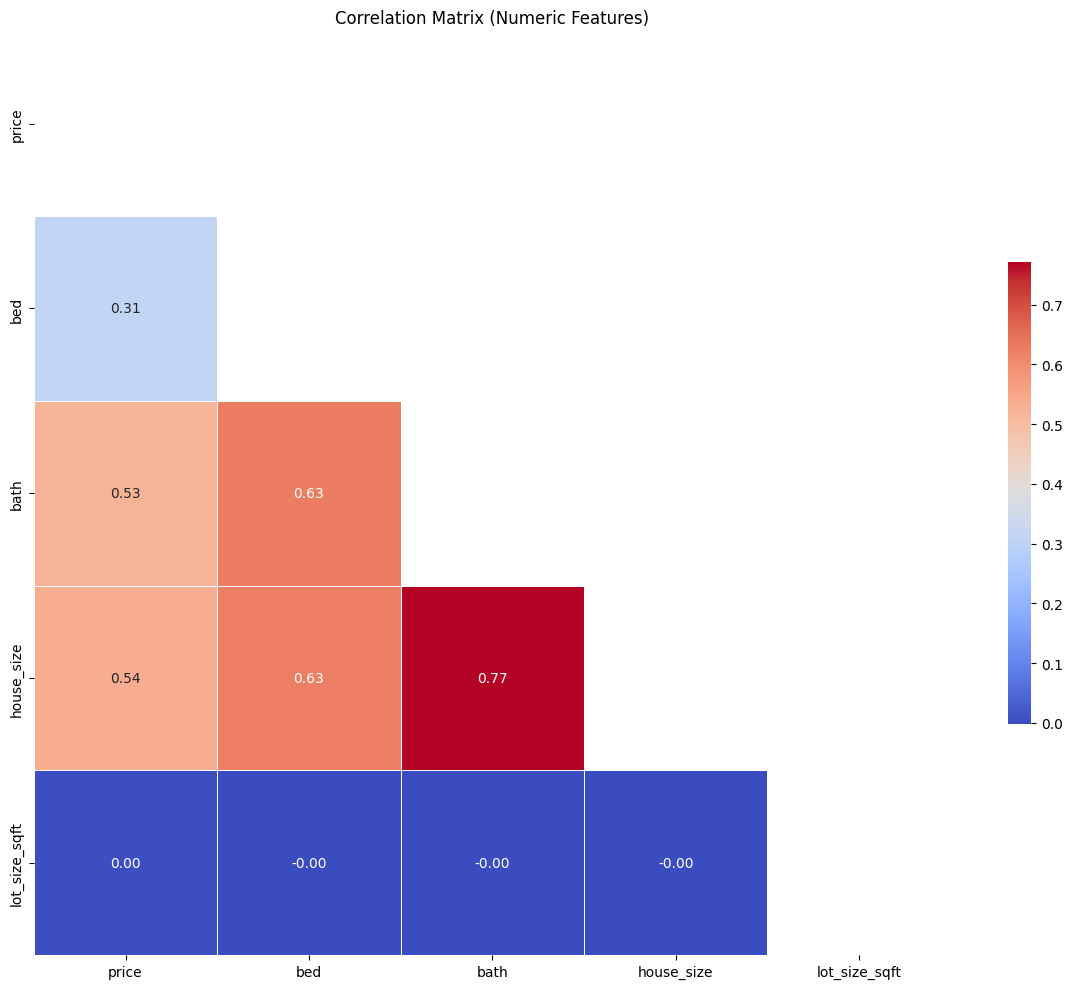

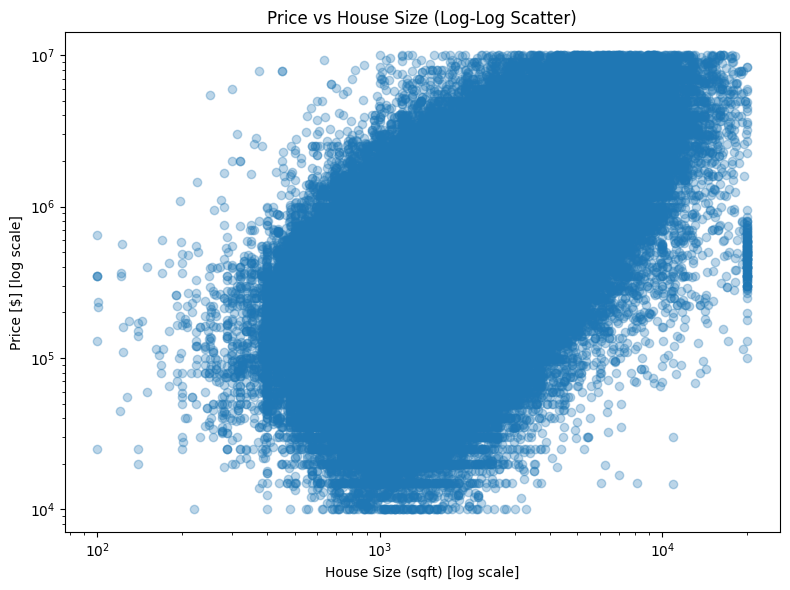

In [10]:
# 6b. ADDITIONAL VISUALIZATIONS: State counts, Median price, Heatmap, Scatter
print("\nGenerating additional visualizations: Listings by state, Median price by state, Correlation heatmap, and Price vs House Size scatter...")

# 1) Listings per State (Top 20)
state_counts = df['state'].value_counts().nlargest(20)
plt.figure(figsize=(12,6))
sns.barplot(x=state_counts.values, y=state_counts.index, palette='viridis')
plt.title('Number of Listings by State (Top 20)')
plt.xlabel('Number of Listings')
plt.ylabel('State')
plt.tight_layout()
plt.show()

# Median price for those same top states
median_price = df.groupby('state')['price'].median().reindex(state_counts.index)
plt.figure(figsize=(12,6))
sns.barplot(x=median_price.values, y=median_price.index, palette='magma')
plt.title('Median Price by State (Top 20 by Listing Count)')
plt.xlabel('Median Price ($)')
plt.ylabel('State')
plt.tight_layout()
plt.show()

# 2) Correlation Heatmap (numeric features)
numeric_cols = df.select_dtypes(include=[np.number])
corr = numeric_cols.corr()
plt.figure(figsize=(12,10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', linewidths=.5, cbar_kws={'shrink': .5})
plt.title('Correlation Matrix (Numeric Features)')
plt.tight_layout()
plt.show()

# 3) Price vs House Size (log-log scatter)
if 'house_size' in df.columns and 'price' in df.columns:
    plt.figure(figsize=(8,6))
    plt.scatter(df['house_size'], df['price'], alpha=0.3)
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('House Size (sqft) [log scale]')
    plt.ylabel('Price [$] [log scale]')
    plt.title('Price vs House Size (Log-Log Scatter)')
    plt.tight_layout()
    plt.show()
else:
    print('Skipping Price vs House Size scatter — required columns missing')

### 9) Save Cleaned Data
Save the cleaned DataFrame to `cleaned_usa_housing.csv` so training scripts can load it quickly without re-running the cleaning pipeline.

In [12]:
# 7. SAVE THE CLEAN FILE
# Save it to a new CSV so your training script loads faster next time
output_filename = 'cleaned_usa_housing.csv'
df.to_csv(output_filename, index=False)
print(f"\nSUCCESS! Clean data saved to: {output_filename}")


SUCCESS! Clean data saved to: cleaned_usa_housing.csv
